## Estadistica Aplicada

Sesion 16 - 24 de Octubre

Bryan Alejandro Estrada Rodriguez 1844554

Grupo: 042


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
pip install pmdarima

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.3 MB/s eta 0:00:00


In [ ]:
# Especializadas
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Importamos modelo ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict


# pmdarima
import pmdarima as pm

In [ ]:
df_amazon = pd.read_excel('amazon.xlsx')

In [ ]:
df_amazon

,fecha,amazon
0,2015-01-02,24.573591
1,2015-01-05,23.830631
2,2015-01-06,24.070295
3,2015-01-07,24.453760
4,2015-01-08,24.301968
...,...,...
1250,2019-12-23,52.589653
1251,2019-12-24,52.599163
1252,2019-12-26,52.561153
1253,2019-12-27,52.865196


In [ ]:
df_amazon.dtypes

fecha     datetime64[ns]
amazon           float64
dtype: object

In [ ]:
ultima_obs =df_amazon.loc[1254]
df_amazon = df_amazon.loc[:1253]

In [ ]:
df_amazon

,fecha,amazon
0,2015-01-02,24.573591
1,2015-01-05,23.830631
2,2015-01-06,24.070295
3,2015-01-07,24.453760
4,2015-01-08,24.301968
...,...,...
1249,2019-12-20,54.128864
1250,2019-12-23,52.589653
1251,2019-12-24,52.599163
1252,2019-12-26,52.561153


In [ ]:
ultima_obs

fecha     2019-12-30 00:00:00
amazon              51.478008
Name: 1254, dtype: object

In [ ]:
df_amazon.dtypes

fecha     datetime64[ns]
amazon           float64
dtype: object

In [ ]:
df_amazon = df_amazon.set_index('fecha')

In [ ]:
df_amazon.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2019-12-13', '2019-12-16', '2019-12-17', '2019-12-18',
               '2019-12-19', '2019-12-20', '2019-12-23', '2019-12-24',
               '2019-12-26', '2019-12-27'],
              dtype='datetime64[ns]', name='fecha', length=1254, freq=None)

In [ ]:
## informacion los dias habiles(bussiness days)
## asignar frecuencia dias habiles
df_amazon = df_amazon.asfreq('B')

In [ ]:
df_amazon.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2019-12-16', '2019-12-17', '2019-12-18', '2019-12-19',
               '2019-12-20', '2019-12-23', '2019-12-24', '2019-12-25',
               '2019-12-26', '2019-12-27'],
              dtype='datetime64[ns]', name='fecha', length=1301, freq='B')

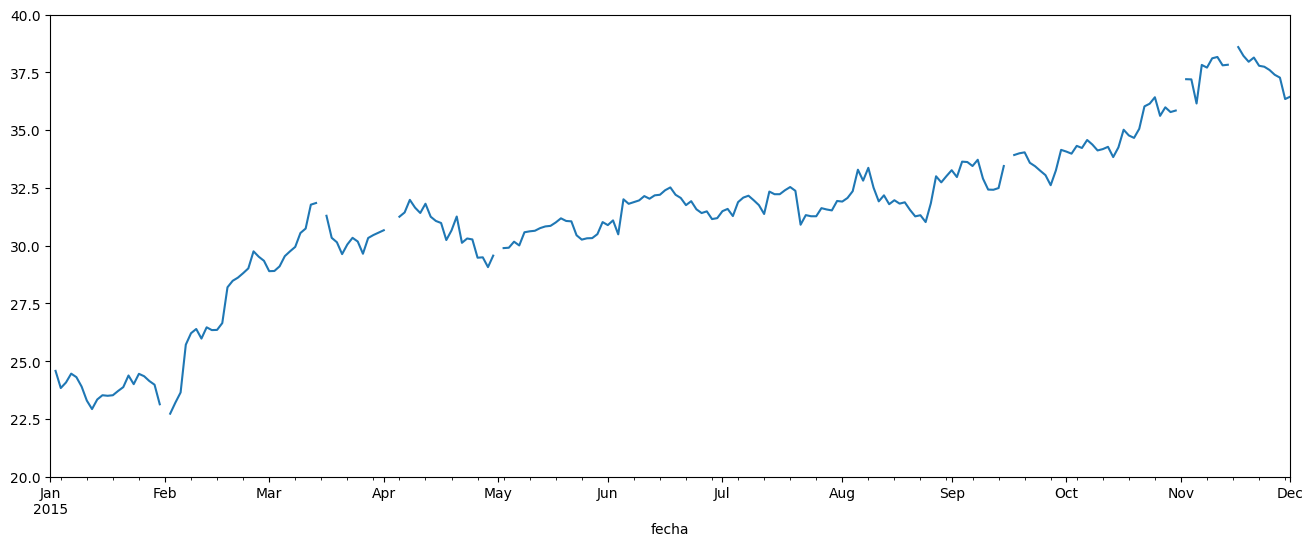

In [ ]:
## grficar
df_amazon['amazon'].plot(figsize=(16,6))
plt.xlim('2015-01-01','2015-12-01')
plt.ylim(20,40);

In [ ]:
df_amazon['amazon'].isnull().sum()


47

In [ ]:
## imputar con el ultimo valor conocido
#poner el ultimo valor
# un dia despues
# Promediar el de un dia antes y uno despues
df_amazon['amazon'] = df_amazon ['amazon'].fillna(method='pad')

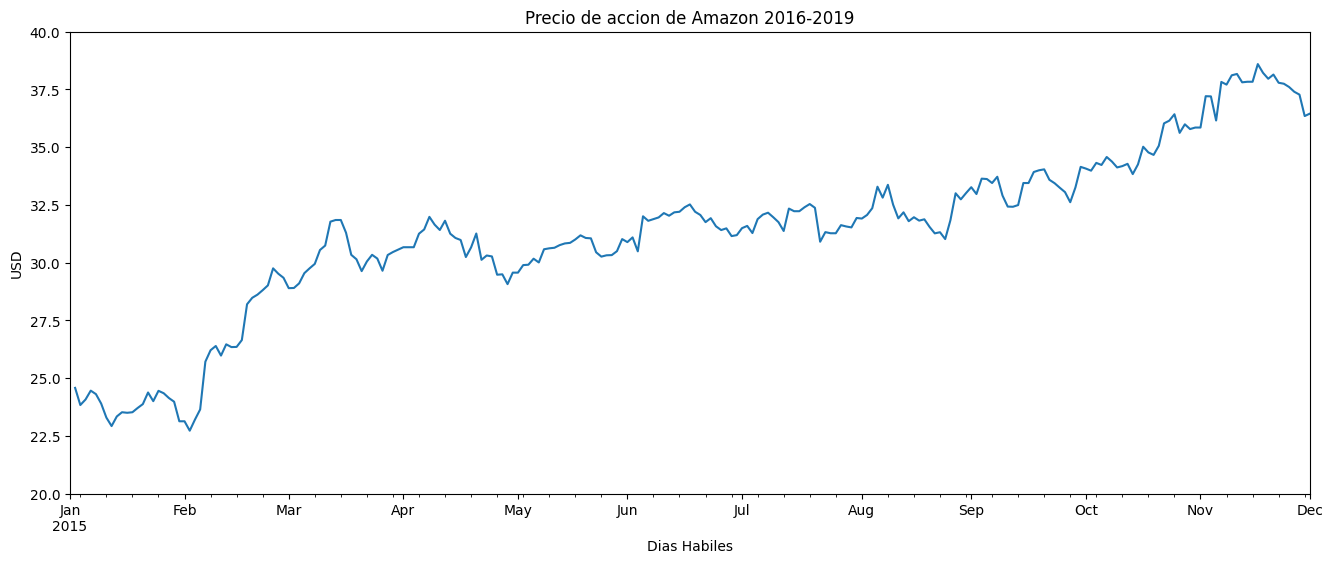

In [ ]:
## grficar
df_amazon['amazon'].plot(figsize=(16,6))
plt.xlim('2015-01-01','2015-12-01')
plt.ylim(20,40)
plt.title('Precio de accion de Amazon 2016-2019')
plt.ylabel('USD')
plt.xlabel('Dias Habiles');

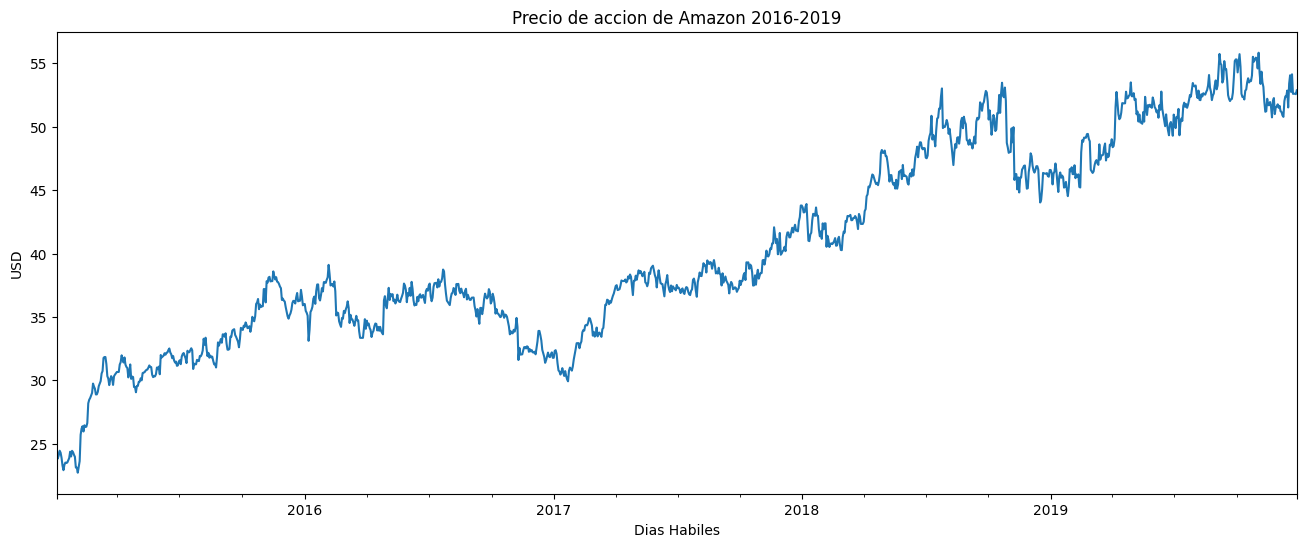

In [ ]:
df_amazon['amazon'].plot(figsize=(16,6))
plt.title('Precio de accion de Amazon 2016-2019')
plt.ylabel('USD')
plt.xlabel('Dias Habiles');

In [ ]:
## es importante que no halla huecos en la serie de tiempo proque puede afetar el pronostico
## prueba de Dickey Fuller
prueba_adf = adfuller(df_amazon['amazon'])
pvalue = prueba_adf[1]
pvalue.round(2)

0.52

No rechazamos H0, el precio de la accion de amazon es una serie no estacionaria

In [ ]:
## APLICAR PRIMERAS DIFERENCIAS
df_amazon['amazon.diff'] = df_amazon['amazon'].diff()

In [ ]:
df_amazon.head()

,amazon,amazon.diff
fecha,,
2015-01-02,24.573591,NaN
2015-01-05,23.830631,-0.742960
2015-01-06,24.070295,0.239664
2015-01-07,24.453760,0.383465
2015-01-08,24.301968,-0.151793


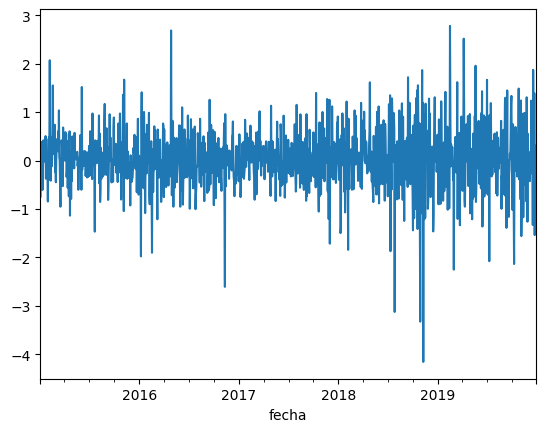

In [ ]:
df_amazon['amazon.diff'].plot();

In [ ]:
prueba_adf1 = adfuller(df_amazon['amazon.diff'].dropna())
pvalue1= prueba_adf1[1]
pvalue1.round(2)

0.0

Rechazamos H0, significa que las primeras diferencias de amazon son una serie estacionaria  
* amazon integrada I(1) = ARIMA (p,q,q)
* 1ras diferencias de amazon I(0) = ARIMA (p,0,q)


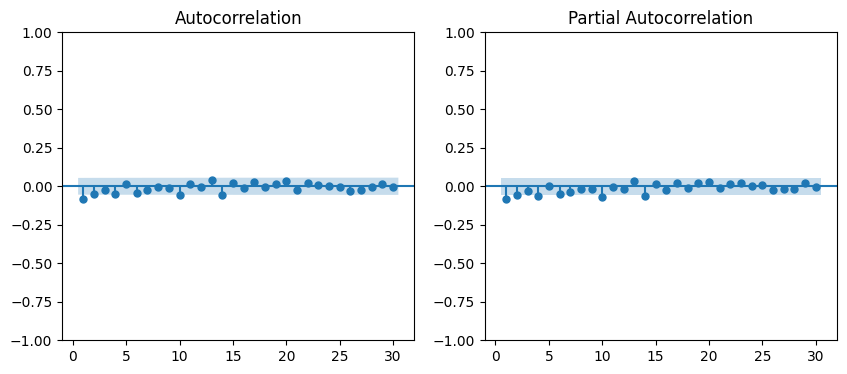

In [ ]:
# grafica de correlacion
ig, ax = plt.subplots(1,2,figsize=(10,4))
#graf1
plot_acf(df_amazon['amazon.diff'].dropna(),zero=False,lags=30,ax=ax[0])
#graf2
plot_pacf(df_amazon['amazon.diff'].dropna(),zero=False,lags=30,ax=ax[1])
plt.show()

In [ ]:
## encontrar el orden del ARIMA
pm.auto_arima(df_amazon['amazon'],
              start_p=1, start_q=1,
              max_p=7, max_q=7,
              ic='aic',
              seasonal = False

)

ARIMA(order=(1, 1, 1), scoring_args={}, suppress_warnings=True)

Amazon es un ARIMA(p=1,1,q=1)=ARIMA(1,1,1)

In [ ]:
pm.auto_arima(df_amazon['amazon.diff'].dropna(),
              start_p=1, start_q=1,
              max_p=7, max_q=7,
              ic='aic',
              seasonal = False
)

ARIMA(order=(1, 0, 1), scoring_args={}, suppress_warnings=True)

1ras diferencias de Amazon es un ARIMA(p=0,1,q=0)=ARIMA(0,0,0
)

In [ ]:
## Pronosticar accion de amazon
model = ARIMA(df_amazon['amazon'],
              order=(1,1,1))
results=model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                 amazon   No. Observations:                 1301
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1183.529
Date:                Tue, 24 Oct 2023   AIC                           2373.058
Time:                        21:29:32   BIC                           2388.569
Sample:                    01-02-2015   HQIC                          2378.878
                         - 12-27-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7500      0.071     10.517      0.000       0.610       0.890
ma.L1         -0.8375      0.059    -14.285      0.000      -0.952      -0.723
sigma2         0.3616      0.008     43.599      0.0

In [ ]:
results.get_prediction

<bound method MLEResults.get_prediction of <statsmodels.tsa.arima.model.ARIMAResults object at 0x7dd4033f4250>>

In [ ]:
results.predict('2019-12-28','2020-01-05')

2019-12-30    52.847340
2019-12-31    52.833947
2020-01-01    52.823902
2020-01-02    52.816367
2020-01-03    52.810716
2020-01-06    52.806478
Freq: B, Name: predicted_mean, dtype: float64

In [ ]:
#Son 6 periodos(steps), por los prectict de arriba
forecast = results.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [ ]:
inicio = '2019-12-30'
final = '2020-01-06'

In [ ]:
pronostico_valor = forecast_mean[inicio:final]
pronosticar_intervalos = forecast_ci.loc[inicio:final]


In [ ]:
pronosticar_intervalos

,lower amazon,upper amazon
2019-12-30,51.668690,54.025990
2019-12-31,51.238282,54.429612
2020-01-01,50.941672,54.706131
2020-01-02,50.712311,54.920423
2020-01-03,50.523484,55.097949
2020-01-06,50.361404,55.251551


In [ ]:
df_pronostico = pd.DataFrame({
    'pronostico': pronostico_valor,
    'limite inferior': pronosticar_intervalos.iloc[:,0],
    'limite superior': pronosticar_intervalos.iloc[:,1]
})

In [ ]:
print(f'El pronostico de la accion de amazon para el dia 30 de dic de 2019 es {df_pronostico.iloc[0,0].round(2)}\ncon un valor minimo de {df_pronostico.iloc[0,1].round(2)}\ncon un valor maximo {df_pronostico.iloc[0,2].round(2)}')

El pronostico de la accion de amazon para el dia 29 de  52.85
con un valor minimo de 51.67
con un valor maximo 54.03


In [ ]:
ultima_obs

fecha     2019-12-30 00:00:00
amazon              51.478008
Name: 1254, dtype: object